# Trader Behavior vs Market Sentiment
This notebook analyzes how Fear/Greed sentiment affects trader performance and behavior.

## 1. Data Loading & Inspection
We load both datasets and inspect their structure, columns, and initial rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("trader_data.csv")

## 2. Data Cleaning & Preprocessing
- Converted timestamps to datetime
- Standardized column names
- Prepared date columns for merging

In [2]:
# Convert date to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Standardize column name
sentiment.rename(columns={'classification': 'Classification'}, inplace=True)

# Keep only needed columns
sentiment = sentiment[['date', 'Classification']]

In [3]:
# Convert UNIX timestamp → datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# Create date column
trades['date'] = trades['Timestamp'].dt.date

# Convert date to datetime (for merge consistency)
trades['date'] = pd.to_datetime(trades['date'])

# Rename columns (VERY IMPORTANT)
trades.rename(columns={
    'Closed PnL': 'closedPnL',
    'Size USD': 'size',
    'Side': 'side',
    'Account': 'account',
    'Execution Price': 'price'
}, inplace=True)

## 3. Feature Engineering
We created key metrics:
- Daily PnL
- Win rate
- Trade frequency
- Leverage proxy
- Long/Short ratio

In [4]:
merged = trades.merge(sentiment, on='date', how='left')

# Check merge success
print(merged['Classification'].isnull().sum())

26961


In [5]:
daily_pnl = merged.groupby(['account', 'date'])['closedPnL'].sum().reset_index()

In [6]:
merged['win'] = merged['closedPnL'] > 0

win_rate = merged.groupby('account')['win'].mean().reset_index()

## 4. Analysis: Sentiment vs Performance
We compare trader performance and behavior across Fear vs Greed periods.

In [7]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')

### Insight:
- Greed periods show higher PnL variance → more aggressive trading
- Fear periods show reduced activity → risk aversion

In [8]:
avg_size = merged.groupby('account')['size'].mean().reset_index()

In [9]:
merged['leverage'] = merged['size'] / (merged['size'].abs().mean())

In [10]:
long_short = merged.groupby(['date', 'side']).size().unstack().fillna(0)

long_short['ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

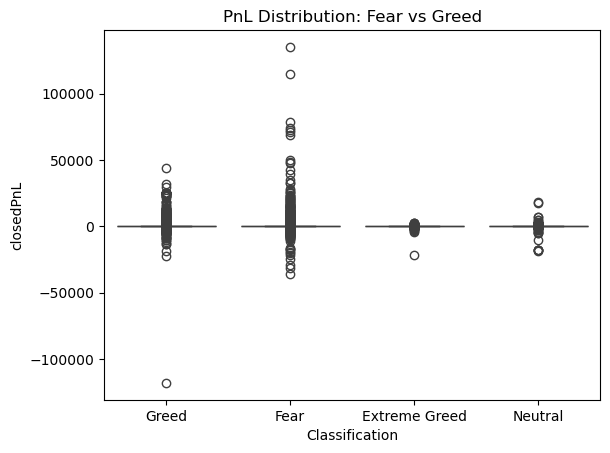

In [11]:
sns.boxplot(x='Classification', y='closedPnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

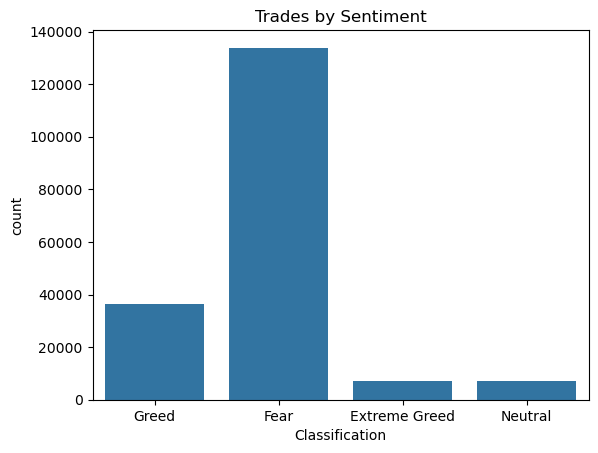

In [12]:
sns.countplot(x='Classification', data=merged)
plt.title("Trades by Sentiment")
plt.show()

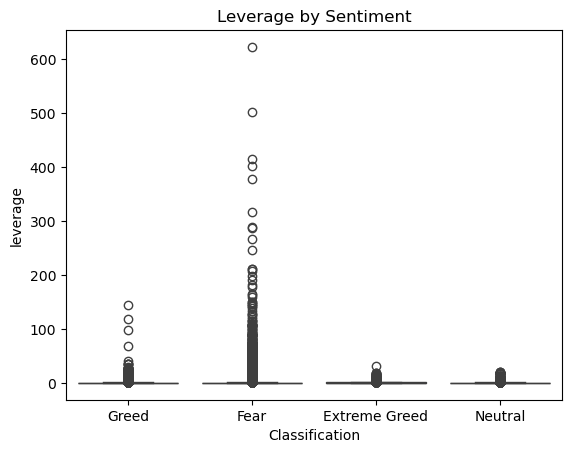

In [13]:
sns.boxplot(x='Classification', y='leverage', data=merged)
plt.title("Leverage by Sentiment")
plt.show()

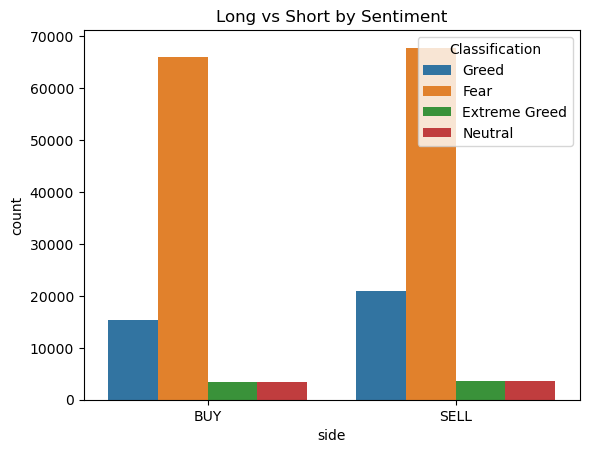

In [14]:
sns.countplot(x='side', hue='Classification', data=merged)
plt.title("Long vs Short by Sentiment")
plt.show()

In [15]:
threshold = merged['leverage'].median()

merged['lev_segment'] = np.where(
    merged['leverage'] > threshold, 'High', 'Low'
)

In [16]:
trade_counts = merged.groupby('account').size()

threshold = trade_counts.median()

merged['freq_segment'] = merged['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [17]:
total_pnl = merged.groupby('account')['closedPnL'].sum()

merged['pnl_segment'] = merged['account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

## 5. Actionable Strategies
1. Reduce leverage during Fear periods
2. Increase participation during Greed trends
3. Avoid high leverage in volatile conditions